In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
# Seed zapewnia identyczne dane u każdego studenta
np.random.seed(42)
n = 200
dzialy = np.random.choice(['IT', 'Sprzedaz', 'HR', 'Marketing', 'Finanse'], n,
p=[0.30, 0.25, 0.15, 0.20, 0.10])
staz = np.random.gamma(shape=3, scale=2, size=n).clip(0.5, 20).round(1)
baza = {'IT': 9000, 'Sprzedaz': 7000, 'HR': 6500, 'Marketing': 7500, 'Finanse':
8500}
wynagrodzenie = np.array([
baza[d] + staz[i] * 300 + np.random.normal(0, 1200)
for i, d in enumerate(dzialy)
]).clip(4000, 25000).round(-2)
# 5 celowo wstawionych outlierów (błędy danych / kontrakty specjalne)
wynagrodzenie[np.random.choice(n, 5, replace=False)] = np.random.choice(
[2000, 2500, 35000, 40000, 38000], 5, replace=False
)
df = pd.DataFrame({
'dzial': dzialy,
'staz_lat': staz,
'wynagrodzenie': wynagrodzenie,
'wiek': (25 + staz + np.random.normal(0, 3, n)).clip(22,
65).round().astype(int),
'ocena_roczna': np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.40,
0.35, 0.10])
})
print(f"Dataset HR: {df.shape[0]} pracowników, {df.shape[1]} kolumn")
print(df.head())
print("\nTypy kolumn:")
print(df.dtypes)

Dataset HR: 200 pracowników, 5 kolumn
       dzial  staz_lat  wynagrodzenie  wiek  ocena_roczna
0   Sprzedaz       3.4         9100.0    27             5
1    Finanse       6.1        12600.0    35             3
2  Marketing       6.3         7700.0    38             3
3         HR       3.3         8200.0    27             4
4         IT      14.0        12400.0    38             4

Typy kolumn:
dzial                str
staz_lat         float64
wynagrodzenie    float64
wiek               int64
ocena_roczna       int64
dtype: object


## Ćw 1

In [3]:
placa = df['wynagrodzenie']

srednia = placa.mean()
mediana = placa.median()
dominanta = placa.mode().iloc[0] 

print("=== MIARY TENDENCJI CENTRALNEJ ===")
print(f"Średnia:   {srednia:>10,.0f} PLN")
print(f"Mediana:   {mediana:>10,.0f} PLN")
print(f"Dominanta: {dominanta:>10,.0f} PLN")

=== MIARY TENDENCJI CENTRALNEJ ===
Średnia:        9,940 PLN
Mediana:        9,450 PLN
Dominanta:      9,500 PLN


In [4]:

odch_std = placa.std() # Domyślnie ddof=1 (próba)
q1 = placa.quantile(0.25)
q3 = placa.quantile(0.75)
iqr = q3 - q1
rozstep = placa.max() - placa.min()

print("=== MIARY ROZPROSZENIA ===")
print(f"Odchylenie std: {odch_std:>10,.0f} PLN")
print(f"Q1 (P25):       {q1:>10,.0f} PLN")
print(f"Q3 (P75):       {q3:>10,.0f} PLN")
print(f"IQR:            {iqr:>10,.0f} PLN")
print(f"Rozstęp:        {rozstep:>10,.0f} PLN")

=== MIARY ROZPROSZENIA ===
Odchylenie std:      3,980 PLN
Q1 (P25):            8,200 PLN
Q3 (P75):           10,700 PLN
IQR:                 2,500 PLN
Rozstęp:            38,000 PLN


In [5]:
dzialy_stats = df.groupby('dzial', observed=True)['wynagrodzenie'].agg([
    'mean', 'median', 'std'
]).round().sort_values('median', ascending=False)

dzialy_stats.columns = ['Średnia', 'Mediana', 'Std']

print("=== WYNAGRODZENIA PER DZIAŁ ===")
print(dzialy_stats)

=== WYNAGRODZENIA PER DZIAŁ ===
           Średnia  Mediana     Std
dzial                              
IT         11108.0  10600.0  4145.0
Finanse    10621.0  10400.0  1741.0
Marketing   9476.0   9100.0  4386.0
HR          8354.0   8400.0  1622.0
Sprzedaz    9282.0   8400.0  4428.0


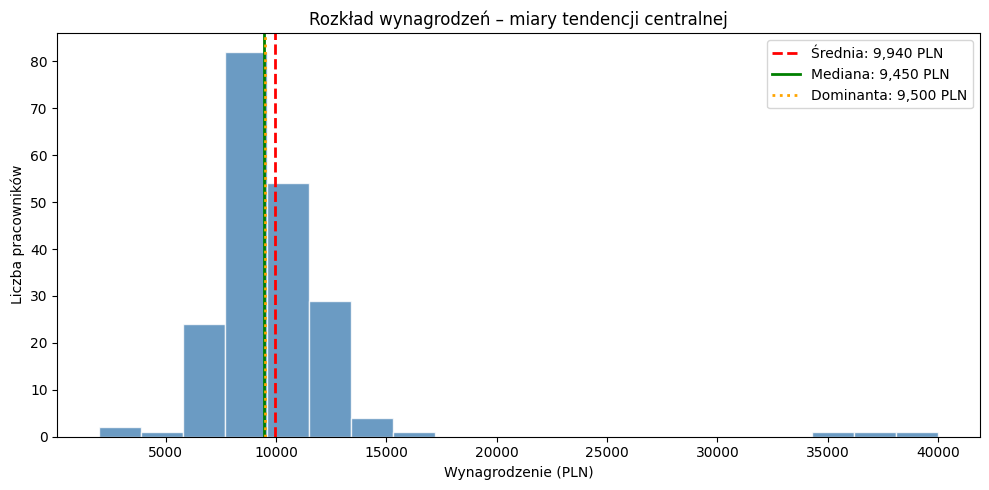

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))


ax.hist(df['wynagrodzenie'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')

ax.axvline(srednia, color='red', linestyle='--', lw=2, label=f'Średnia: {srednia:,.0f} PLN')
ax.axvline(mediana, color='green', linestyle='-', lw=2, label=f'Mediana: {mediana:,.0f} PLN')
ax.axvline(dominanta, color='orange', linestyle=':', lw=2, label=f'Dominanta: {dominanta:,.0f} PLN')

ax.set_title('Rozkład wynagrodzeń – miary tendencji centralnej')
ax.set_xlabel('Wynagrodzenie (PLN)')
ax.set_ylabel('Liczba pracowników')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

## Ćw 2

In [7]:
r, p_value = stats.pearsonr(df['staz_lat'], df['wynagrodzenie'])
print(f"Korelacja Pearsona (staż-wynagrodzenie):")
print(f"  r = {r:.4f}")
print(f"  p = {p_value:.4f}")
print(f"  Interpretacja: {'istotna' if p_value < 0.05 else 'nieistotna'} statystycznie")

Korelacja Pearsona (staż-wynagrodzenie):
  r = 0.3198
  p = 0.0000
  Interpretacja: istotna statystycznie


In [8]:
rho, p_rho = stats.spearmanr(df['staz_lat'], df['wynagrodzenie'])
print(f"\nKorelacja Spearmana (staż-wynagrodzenie):")
print(f"  rho = {rho:.4f}")
print(f"  p   = {p_rho:.4f}")

print(f"\nPorównanie: Pearson r={r:.3f} vs Spearman rho={rho:.3f}")
print(f"Różnica: {abs(rho - r):.3f} — {'duże' if abs(rho - r) > 0.1 else 'małe'} rozbieżności")


Korelacja Spearmana (staż-wynagrodzenie):
  rho = 0.5219
  p   = 0.0000

Porównanie: Pearson r=0.320 vs Spearman rho=0.522
Różnica: 0.202 — duże rozbieżności


Macierz korelacji Pearsona:
               staz_lat  wynagrodzenie   wiek  ocena_roczna
staz_lat          1.000          0.320  0.756        -0.057
wynagrodzenie     0.320          1.000  0.219        -0.054
wiek              0.756          0.219  1.000        -0.081
ocena_roczna     -0.057         -0.054 -0.081         1.000


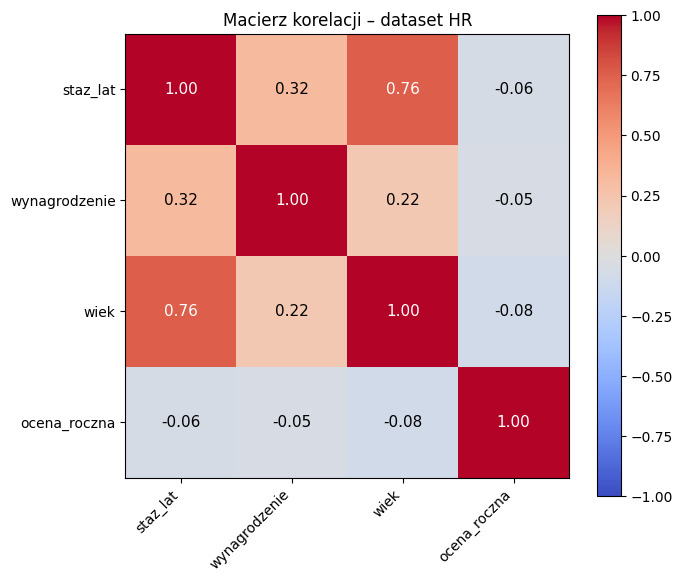

In [ ]:
corr = df[['staz_lat', 'wynagrodzenie', 'wiek', 'ocena_roczna']].corr()
print("Macierz korelacji Pearsona:")
print(corr.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}',
                ha='center', va='center', fontsize=11,
                color='black' if abs(corr.values[i, j]) < 0.7 elbse 'white')

ax.set_title('Macierz korelacji – dataset HR')
plt.tight_layout()
plt.show()
plt.close()

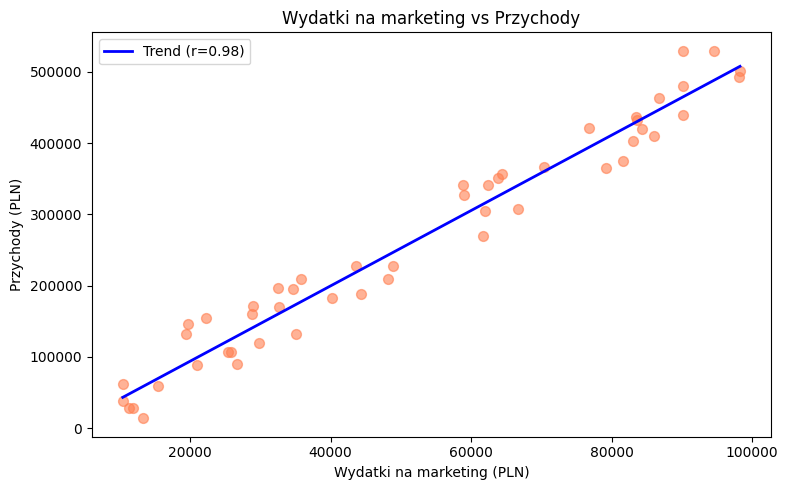

Marketing spend vs Revenue: r = 0.9806, p = 1.22e-35


In [10]:
np.random.seed(100)
n_mkt = 50
marketing_spend = np.random.uniform(10000, 100000, n_mkt)
revenue = marketing_spend * 5.2 + np.random.normal(0, 30000, n_mkt)
revenue = revenue.clip(0)


r_mkt, p_mkt = stats.pearsonr(marketing_spend, revenue)


fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(marketing_spend, revenue, alpha=0.6, color='coral', s=50)


z = np.polyfit(marketing_spend, revenue, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(marketing_spend.min(), marketing_spend.max(), 100)
ax.plot(x_line, p_fit(x_line), 'b', lw=2, label=f'Trend (r={r_mkt:.2f})')

ax.set_title('Wydatki na marketing vs Przychody')
ax.set_xlabel('Wydatki na marketing (PLN)')
ax.set_ylabel('Przychody (PLN)')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

print(f"Marketing spend vs Revenue: r = {r_mkt:.4f}, p = {p_mkt:.2e}")

## Ćw 3

In [11]:
opis = stats.describe(df['wynagrodzenie'])
print(f"Liczba obserwacji (nobs): {opis.nobs}")
print(f"Min: {opis.minmax[0]:,.0f} PLN, Max: {opis.minmax[1]:,.0f} PLN")
print(f"Średnia: {opis.mean:,.0f} PLN")
print(f"Wariancja: {opis.variance:,.0f}")
print(f"Skośność: {opis.skewness:.3f}")
print(f"Kurtoza: {opis.kurtosis:.3f}")

Liczba obserwacji (nobs): 200
Min: 2,000 PLN, Max: 40,000 PLN
Średnia: 9,940 PLN
Wariancja: 15,838,191
Skośność: 5.102
Kurtoza: 34.159


In [12]:
percentyle_wartosci = [10, 25, 50, 75, 90, 95, 99]
wyniki_pct = np.percentile(df['wynagrodzenie'], percentyle_wartosci)

for pct, kwota in zip(percentyle_wartosci, wyniki_pct):
    print(f"P{pct}: {kwota:>10,.0f} PLN")

p75 = wyniki_pct[3]
odsetek_powyzej_12k = (df['wynagrodzenie'] > 12000).mean() * 100
print(f"\nOdpowiedź 1: Progiem P75 rynkowego benchmarku jest kwota: {p75:,.0f} PLN.")
print(f"Odpowiedź 2: Powyżej 12 000 PLN zarabia około {odsetek_powyzej_12k:.1f}% pracowników.")

P10:      7,190 PLN
P25:      8,200 PLN
P50:      9,450 PLN
P75:     10,700 PLN
P90:     12,310 PLN
P95:     13,105 PLN
P99:     35,030 PLN

Odpowiedź 1: Progiem P75 rynkowego benchmarku jest kwota: 10,700 PLN.
Odpowiedź 2: Powyżej 12 000 PLN zarabia około 13.0% pracowników.


           Średnia  Mediana     Std     Min      Max     IQR
dzial                                                       
IT         11108.0  10600.0  4145.0  2500.0  40000.0  2750.0
Finanse    10621.0  10400.0  1741.0  8300.0  16200.0  2000.0
Marketing   9476.0   9100.0  4386.0  2000.0  35000.0  1500.0
HR          8354.0   8400.0  1622.0  4500.0  10800.0  2425.0
Sprzedaz    9282.0   8400.0  4428.0  5900.0  38000.0  2075.0


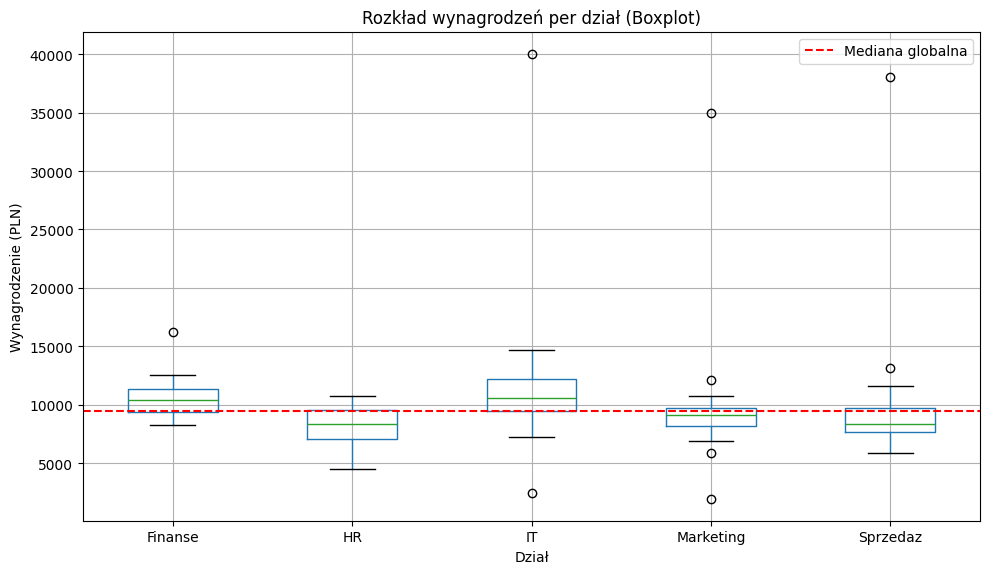

In [13]:

tabela_dzialow = df.groupby('dzial', observed=True)['wynagrodzenie'].agg([
    ('Średnia', 'mean'),
    ('Mediana', 'median'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('IQR', lambda x: x.quantile(0.75) - x.quantile(0.25))
]).round().sort_values('Mediana', ascending=False)

print(tabela_dzialow)

fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='wynagrodzenie', by='dzial', ax=ax)
ax.axhline(df['wynagrodzenie'].median(), color='red', linestyle='--', label='Mediana globalna')

ax.set_title('Rozkład wynagrodzeń per dział (Boxplot)')
ax.set_xlabel('Dział')
ax.set_ylabel('Wynagrodzenie (PLN)')
plt.suptitle('') # Usunięcie automatycznego podtytułu pandas
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

In [14]:
for d in ['IT', 'HR']:
    podzb = df[df['dzial'] == d]['wynagrodzenie']
    opis_d = stats.describe(podzb)
    print(f"\n{d} (n={opis_d.nobs}):")
    print(f"  Skośność: {opis_d.skewness:.3f}")
    print(f"  Kurtoza:  {opis_d.kurtosis:.3f}")


IT (n=66):
  Skośność: 5.067
  Kurtoza:  34.256

HR (n=24):
  Skośność: -0.460
  Kurtoza:  -0.404


## Ćw 4

In [15]:

q1 = df['wynagrodzenie'].quantile(0.25)
q3 = df['wynagrodzenie'].quantile(0.75)
iqr = q3 - q1
dolna = q1 - 1.5 * iqr
gorna = q3 + 1.5 * iqr

print(f"IQR granice: [{dolna:,.0f} PLN, {gorna:,.0f} PLN]")

maska_iqr = (df['wynagrodzenie'] < dolna) | (df['wynagrodzenie'] > gorna)
outliery_iqr = df[maska_iqr]
print(f"Liczba outlierów IQR: {maska_iqr.sum()} z {len(df)}")
print(outliery_iqr[['dzial', 'staz_lat', 'wynagrodzenie']].to_string())

z_scores = np.abs(stats.zscore(df['wynagrodzenie']))
maska_z = z_scores > 3.0
outliery_z = df[maska_z]

print(f"\nOutlierzy z-score (z > 3.0): {maska_z.sum()} obserwacji")
print(outliery_z[['dzial', 'staz_lat', 'wynagrodzenie']].to_string())

IQR granice: [4,450 PLN, 14,450 PLN]
Liczba outlierów IQR: 7 z 200
         dzial  staz_lat  wynagrodzenie
51   Marketing       3.1         2000.0
61          IT      10.6        14700.0
79          IT       6.3        40000.0
83          IT       8.8         2500.0
138   Sprzedaz      13.8        38000.0
154    Finanse      15.3        16200.0
183  Marketing       3.7        35000.0

Outlierzy z-score (z > 3.0): 3 obserwacji
         dzial  staz_lat  wynagrodzenie
79          IT       6.3        40000.0
138   Sprzedaz      13.8        38000.0
183  Marketing       3.7        35000.0


In [16]:
bez_outlierow = df[~maska_iqr]['wynagrodzenie']
z_outlierami = df['wynagrodzenie']

print(f"{'Miara': <20} {'Z outlierami':>15} {'Bez outlierów':>15} {'Zmiana':>10}")
print("-" * 62)

for nazwa, f_z, f_bez in [
    ('Średnia', z_outlierami.mean(), bez_outlierow.mean()),
    ('Mediana', z_outlierami.median(), bez_outlierow.median()),
    ('Std', z_outlierami.std(), bez_outlierow.std())
]:
    zmiana = f_z - f_bez
    print(f"{nazwa: <20} {f_z:>15,.0f} {f_bez:>15,.0f} {zmiana:>+10,.0f}")

Miara                   Z outlierami   Bez outlierów     Zmiana
--------------------------------------------------------------
Średnia                        9,940           9,532       +408
Mediana                        9,450           9,400        +50
Std                            3,980           1,798     +2,182
